In [143]:
# # Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter)
# get_ipython().run_line_magic('run', '../_setup.py')

In [159]:
import calendar

from statsmodels.tsa.seasonal import MSTL
from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from pathlib import Path 
from IPython.display import display

In [145]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

d:\Documents\GitHub\-Time-Series-Analysis-and-Forecasting-methods-\data


In [146]:
def plot_each_series(x):
    for name, df in x.items():
        print(f"--- Đang hiển thị visual cho: {name} ---")
        
        # Gọi Nixtla để lấy đối tượng Figure
        fig = plot_series(
            df=df, 
            id_col="unique_id", 
            time_col="ds", 
            target_col="y",
            engine="matplotlib"
        )
        
        # 1. Thêm tiêu đề tổng cho cả cụm biểu đồ
        fig.suptitle(f"Dataset: {name}", fontsize=16, fontweight='bold', y=1.05)
        
        # 2. Duyệt qua từng biểu đồ con (axes) để thêm label
        for ax in fig.axes:
            ax.set_xlabel("Thời gian (ds)")
            ax.set_ylabel("Giá trị (y)")
            
        # 3. Tự động căn chỉnh để không bị dính chữ
        fig.tight_layout()
        
        # 4. Hiển thị đối tượng figure
        display(fig) 

### 1. Consider the GDP information in global_economy. Plot the GDP per capita for each country over time. Which country has the highest GDP per capita? How has this changed over time?

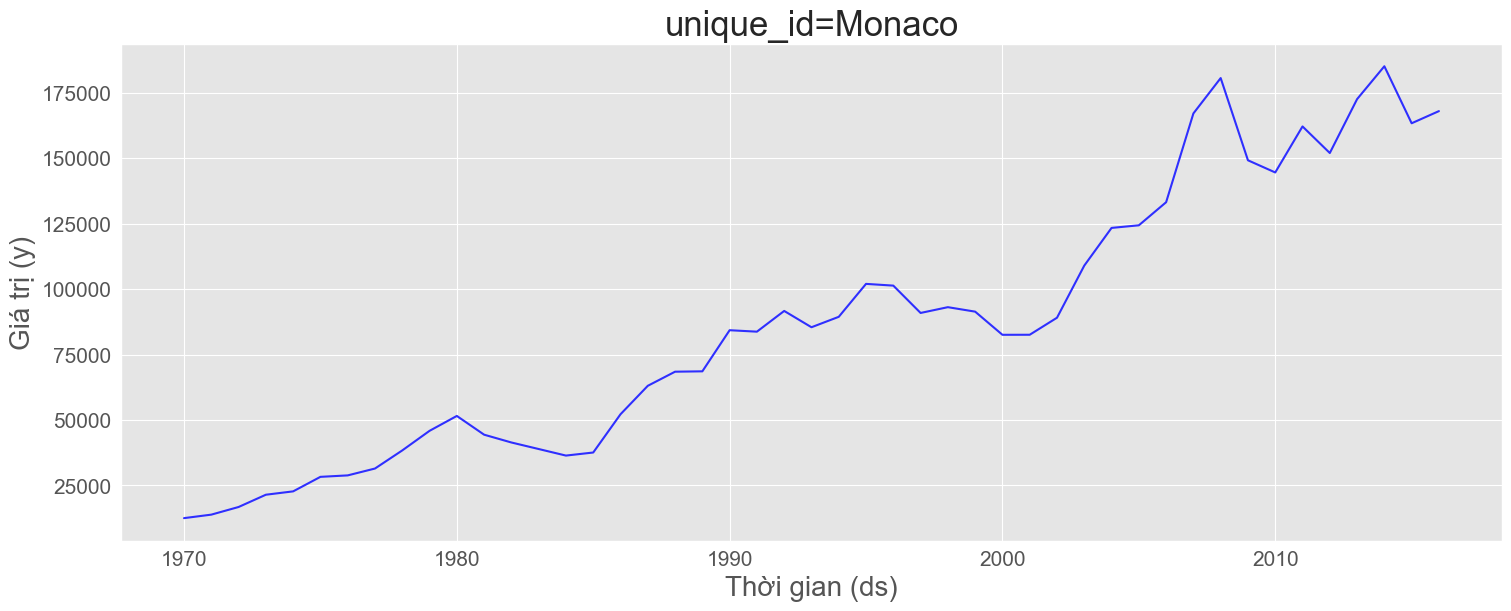

In [147]:
global_economy = (
    pd.read_csv(DATA_DIR / 'global_economy.csv')
    .assign(y = lambda x: x['GDP']/x['Population'])
    )

# because there are too many countries in this dataset. So, I suggests you shouldn't run this code.
# countries = global_economy['unique_id'].unique()

# for country in countries:
#     print(f"--- Đang hiển thị visual cho: {country} ---")

#     # Bước quan trọng để lọc từng origin
#     ddf_filtered = global_economy.query("unique_id == @country")
    
#     fig = plot_series(
#         df = df_filtered, 
#         id_col = "unique_id", 
#         time_col = "ds",
#         target_col = "y",
#         engine = "matplotlib"
#     )
#     for ax in fig.axes:
#                 ax.set_xlabel("Thời gian (ds)")
#                 ax.set_ylabel("Giá trị (y)")
#     # Hiển thị
#     display(fig)

# the highest GDP per-capita
global_economy.sort_values(by = 'y', ascending= False).head(1)
df_monaco = global_economy[global_economy['unique_id'] == 'Monaco']
fig = plot_series(df_monaco)
for ax in fig.axes:
    ax.set_xlabel("Thời gian (ds)")
    ax.set_ylabel("Giá trị (y)")
display(fig)

### 2. For each of the following series, make a graph of the data. If transforming seems appropriate, do so and describe the effect.

- United States GDP from `global_economy`.
- Slaughter of Victorian “Bulls, bullocks and steers” in `aus_livestock`.
- Victorian Electricity Demand from `vic_elec`.
- Gas production from `aus_production`.

In [148]:
global_economy = pd.read_csv(DATA_DIR / "global_economy.csv", parse_dates = ['ds'])
us_gdp = global_economy[global_economy['unique_id'] == 'United States'].copy()
us_gdp['y']  =  us_gdp['GDP'] / us_gdp['Population']

aus_livestock = pd.read_csv(DATA_DIR / 'aus_livestock.csv', parse_dates = ['ds'])
aus = aus_livestock[aus_livestock['unique_id'] == 'Victoria_Bulls, bullocks and steers']
aus['Days_in_month'] = aus['ds'].dt.daysinmonth
aus['y'] = aus['y'] / aus['Days_in_month']

# vic_elec = pd.read_csv(DATA_DIR / "vic_elec.csv", parse_dates = ['ds'])
# vic_elec = vic_elec[vic_elec['unique_id'] == 'Demand']
# vic_elec['ds'] = pd.to_datetime(vic_elec['ds'])
# vic_elec.set_index('ds', inplace=True)
# daily_demand = vic_elec['y'].resample('D').sum()

aus_production = (
    pd.read_csv(DATA_DIR / 'aus_production.csv', parse_dates = ['ds'])
    .rename(columns = {'Gas': 'y'})
    .assign(unique_id="Gas")
    [['ds', 'unique_id', 'y']]
)
y = aus_production["y"].to_numpy()
optim_lambda = boxcox_lambda(y, method="guerrero", season_length=4)
aus_gas = aus_production.assign(y=boxcox(y, optim_lambda))


--- Đang hiển thị visual cho: us_gdp ---


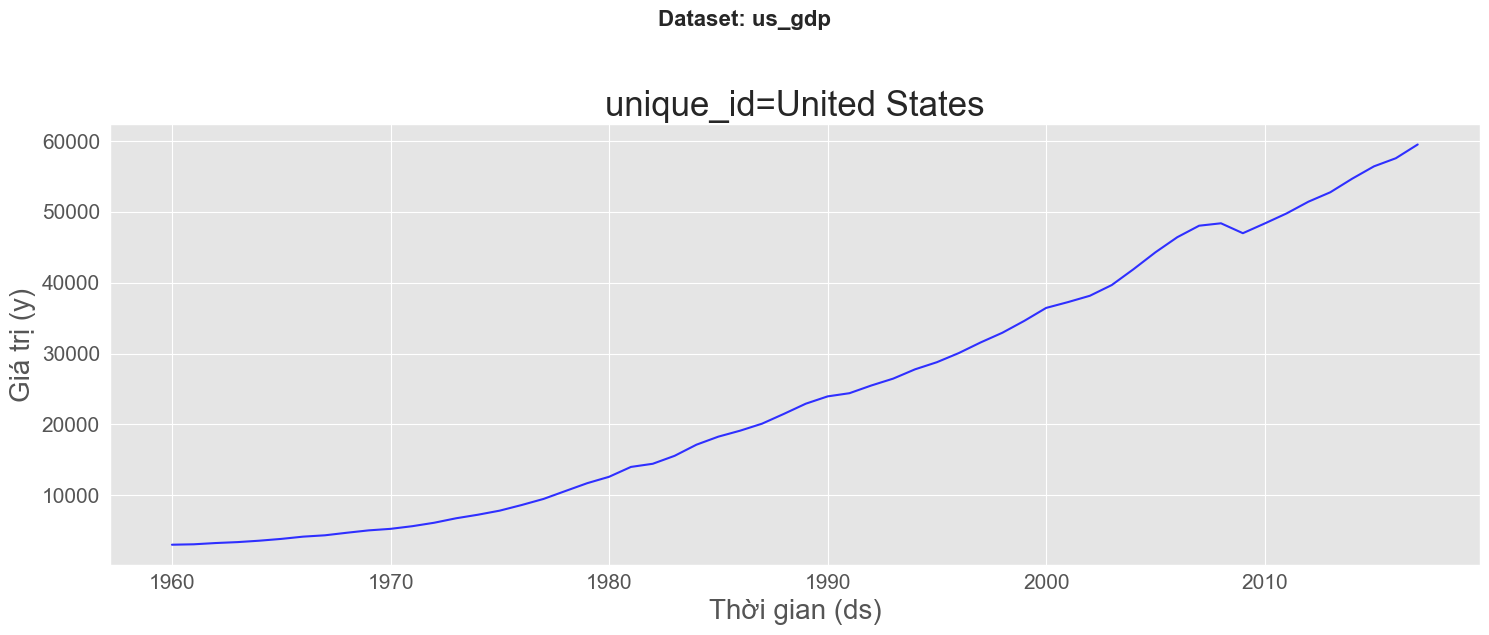

--- Đang hiển thị visual cho: aus_livestock ---


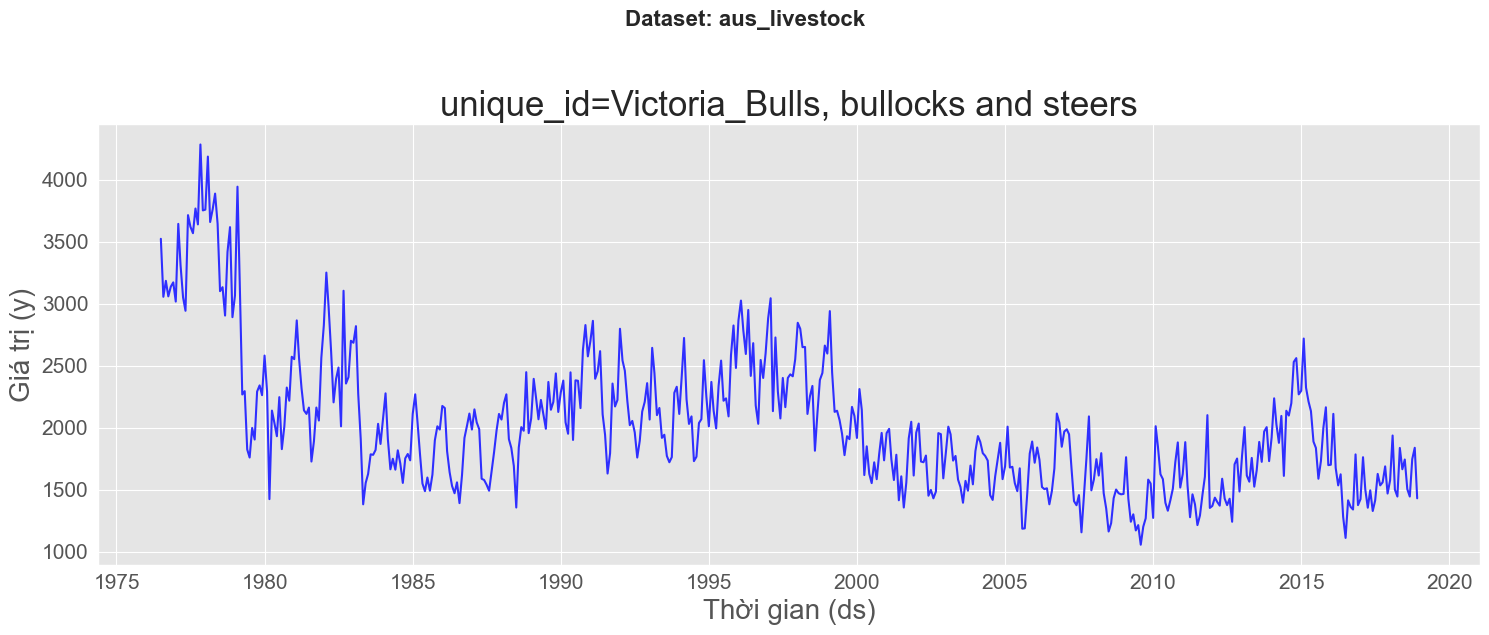

--- Đang hiển thị visual cho: aus_production ---


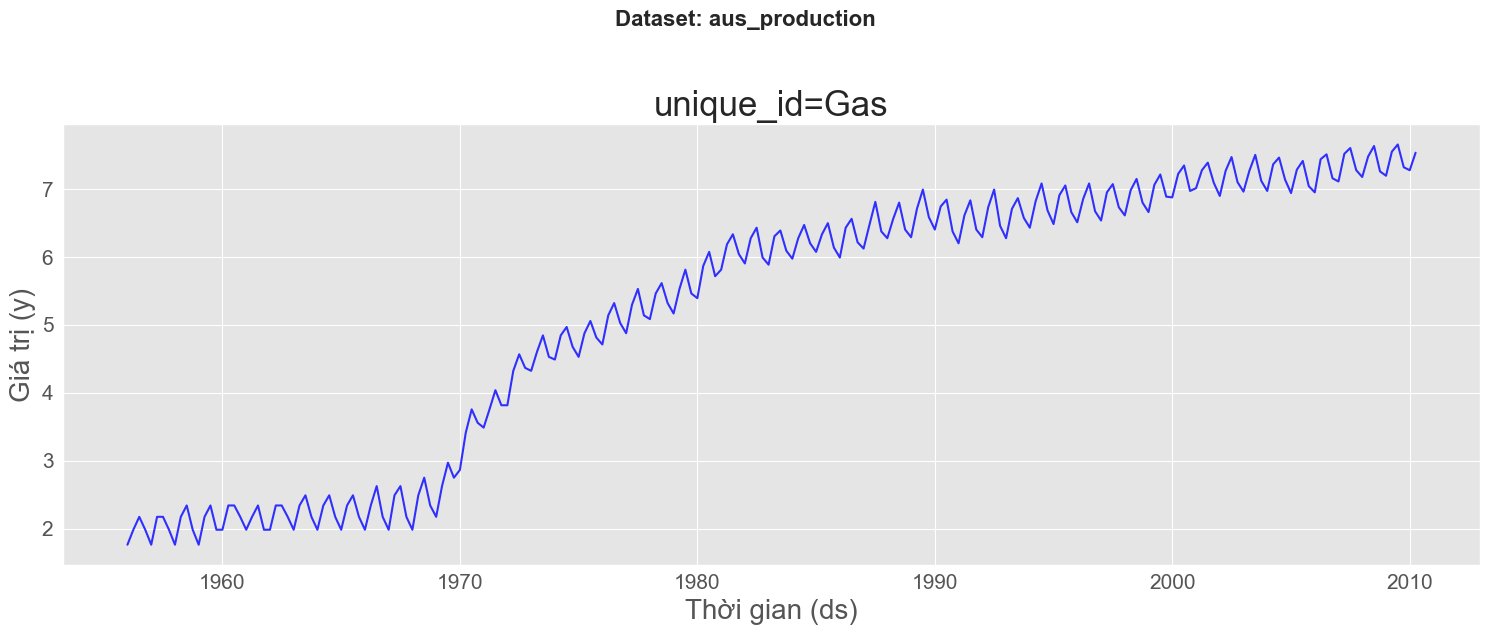

In [149]:
datasets = {"us_gdp": us_gdp,
            "aus_livestock": aus,
            "aus_production": aus_gas}

plot_each_series(datasets)

### 3. Why is a Box-Cox transformation unhelpful for the canadian_gas data?

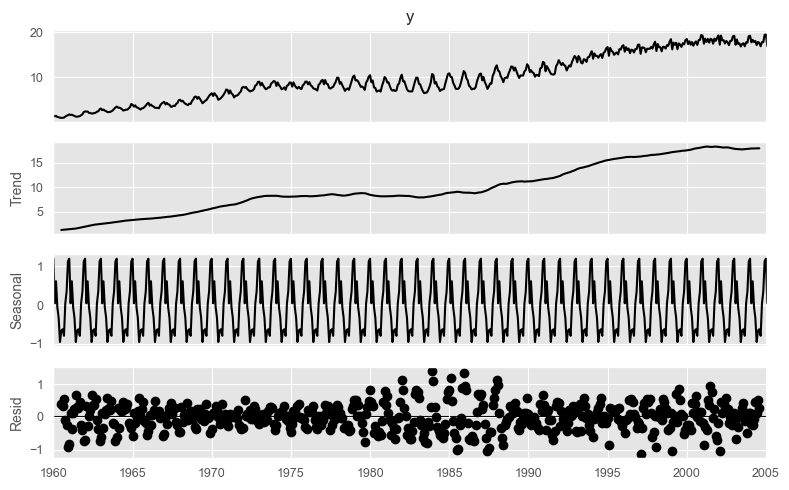

In [150]:
canadian_gas = pd.read_csv(DATA_DIR / 'canadian_gas.csv', parse_dates = ['ds'])
canadian_gas

# plot_series(canadian_gas)
x_series = canadian_gas.set_index('ds')['y']
fig2 = seasonal_decompose(x=x_series, model="additive", period=12)
fig2.plot()
plt.show()

The primary purpose of the Box-Cox transform in time series is to stabilize variance – that is, to make the amplitude of the "waves" (seasonality) fluctuate evenly and equally from beginning to end of the graph, regardless of whether the overall trend is increasing or decreasing.

As we can see in a above plot, the data distribution is bulging in the middle, while the two ends have very small waves. If we apply Box-Cox transformation to compress in the middle part, then that very compressive force would crush and completely distort the data in the later stage (because by then the waveform is already small). So, the Box-Cox transformation will be unhelpful to scale the data.   

### 4. What Box-Cox transformation would you select for your retail data (from Exercise 7 in Section 2.10)?

0.15998490330302254


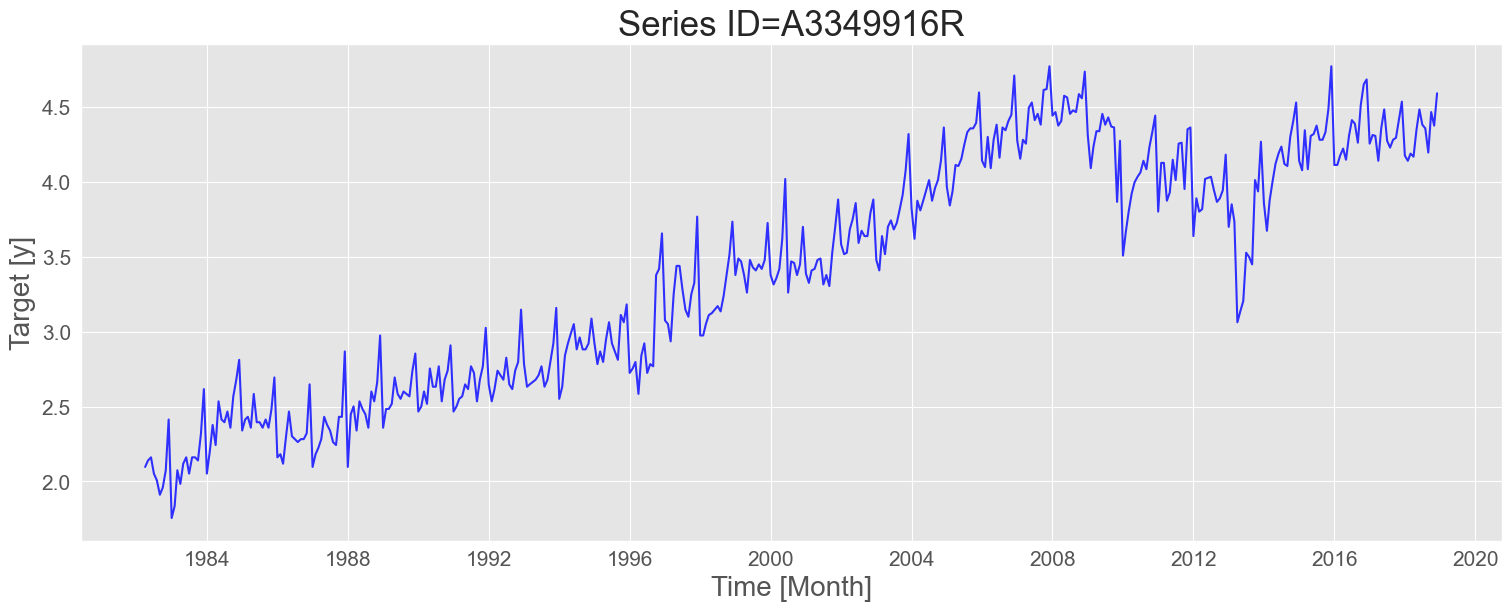

In [151]:
aus_retail = pd.read_csv(DATA_DIR / "aus_retail.csv", parse_dates = ['Month'])
aus_retail

random = np.random.RandomState(42)
random_series_id = random.choice(aus_retail["Series ID"].unique())
myseries = aus_retail.loc[aus_retail["Series ID"] == random_series_id]
myseries
y = myseries['Turnover'].to_numpy()
optim_lambda = boxcox_lambda(y , method = 'guerrero', season_length = 12)
print(optim_lambda)
df = myseries.assign(y = boxcox(y, optim_lambda))
plot_series(df, time_col = 'Month', id_col = 'Series ID', target_col = 'y')

From 1984 to 2020, the general trend was that as revenue increased, the amplitude of fluctuations (the distance between seasonal peaks and troughs) also widened proportionally. This very regular, funnel-shaped expansion is known as multiplicative seasonality.



### 5. For the following series, find an appropriate Box-Cox transformation in order to stabilise the variance. Tobacco from `aus_production`, Economy class passengers between Melbourne and Sydney from `ansett`, and Pedestrian counts at Southern Cross Station from `pedestrian`.

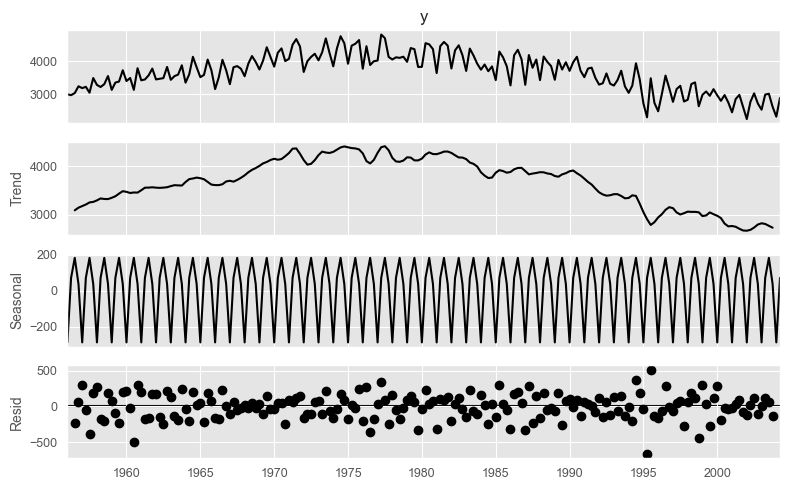

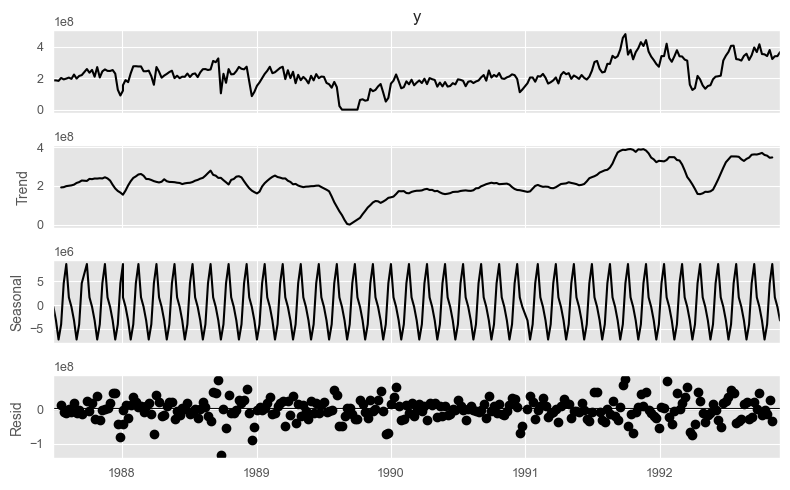

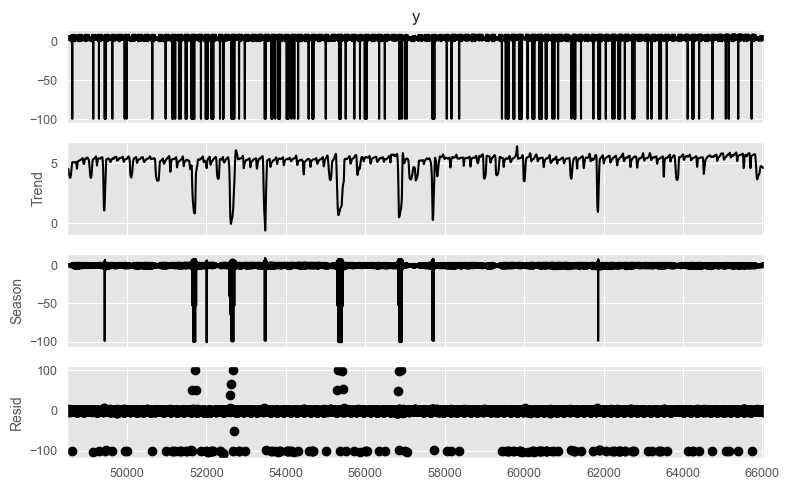

In [152]:
tobacco = (
    pd.read_csv(DATA_DIR / 'aus_production.csv', parse_dates = ['ds'])
    .assign(unique_id = 'Tobacco')
    .dropna()
)
y = tobacco['Tobacco'].to_numpy()
optim_lambda = boxcox_lambda(y, method = 'guerrero', season_length = 4)
df_tobacco = tobacco.assign(y = boxcox(y, optim_lambda))

x_series = df_tobacco.set_index('ds')['y']
fig1 = seasonal_decompose(x=x_series, model="additive", period=4)
fig1.plot()
plt.show()

ansett = (
    pd.read_csv(DATA_DIR / 'ansett.csv', parse_dates = ['ds'])
    .query("Airports == 'MEL-SYD' and Class == 'Economy'")
    .assign(unique_id = 'MEL-SYD-Eco') 
    [['ds', 'unique_id', 'y']]
)
y = ansett['y'].to_numpy()
optim_lambda = boxcox_lambda(y, method = 'guerrero', season_length= 7)
df_ansett = ansett.assign(y = boxcox(y, optim_lambda))

x_series = df_ansett.set_index('ds')['y']
fig2 = seasonal_decompose(x=x_series, model="additive", period=7)
fig2.plot()
plt.show()

ped = (
    pd.read_csv(DATA_DIR / "pedestrian.csv", parse_dates = ['Date_Time'])
    .query("unique_id == 'Southern Cross Station'")
)
y = ped['y'].to_numpy()
optim_lambda = boxcox_lambda(y, method = 'guerrero', season_length= 24)
df_ped = ped.assign(y = boxcox(y, optim_lambda))
stl = STL(df_ped['y'], period=24, robust = True)
res = stl.fit()
res.plot()
plt.show()

### 6. Show that a $3×5$ MA is equivalent to a 7-term weighted moving average with weights of 0.067, 0.133, 0.200, 0.200, 0.200, 0.133, and 0.067.

#### 1. Định nghĩa các bộ lọc thành phần

* **Bộ lọc 5-MA ($L_5$):** Có 5 trọng số bằng nhau, mỗi trọng số là $\frac{1}{5} = 0.2$.
* Dãy trọng số: $W_5 = [0.2, 0.2, 0.2, 0.2, 0.2]$


* **Bộ lọc 3-MA ($L_3$):** Có 3 trọng số bằng nhau, mỗi trọng số là $\frac{1}{3} \approx 0.333$.
* Dãy trọng số: $W_3 = [\frac{1}{3}, \frac{1}{3}, \frac{1}{3}]$



#### 2. Khai triển tích chập (Convolution)

Bộ lọc $3 \times 5$ MA thực chất là việc áp dụng bộ lọc 3-MA lên kết quả đã được xử lý bởi bộ lọc 5-MA. Trọng số cuối cùng là kết quả của phép nhân chập giữa $W_5$ và $W_3$.

Ta có bảng tính toán trọng số tổng hợp tại các thời điểm xung quanh $t$:

| Vị trí | $t-3$ | $t-2$ | $t-1$ | $t$ | $t+1$ | $t+2$ | $t+3$ |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **Trọng số từ $MA_3$ tại $t-1$** | $0.2 \cdot \frac{1}{3}$ | $0.2 \cdot \frac{1}{3}$ | $0.2 \cdot \frac{1}{3}$ | $0.2 \cdot \frac{1}{3}$ | $0.2 \cdot \frac{1}{3}$ |  |  |
| **Trọng số từ $MA_3$ tại $t$** |  | $0.2 \cdot \frac{1}{3}$ | $0.2 \cdot \frac{1}{3}$ | $0.2 \cdot \frac{1}{3}$ | $0.2 \cdot \frac{1}{3}$ | $0.2 \cdot \frac{1}{3}$ |  |
| **Trọng số từ $MA_3$ tại $t+1$** |  |  | $0.2 \cdot \frac{1}{3}$ | $0.2 \cdot \frac{1}{3}$ | $0.2 \cdot \frac{1}{3}$ | $0.2 \cdot \frac{1}{3}$ | $0.2 \cdot \frac{1}{3}$ |
| **Tổng phân số** | $\mathbf{\frac{1}{15}}$ | $\mathbf{\frac{2}{15}}$ | $\mathbf{\frac{3}{15}}$ | $\mathbf{\frac{3}{15}}$ | $\mathbf{\frac{3}{15}}$ | $\mathbf{\frac{2}{15}}$ | $\mathbf{\frac{1}{15}}$ |
| **Giá trị thập phân** | **0.067** | **0.133** | **0.200** | **0.200** | **0.200** | **0.133** | **0.067** |

#### 3. Kết luận

Kết quả tính toán cho thấy dãy trọng số tổng hợp là:


$$W_{final} = [0.067, 0.133, 0.200, 0.200, 0.200, 0.133, 0.067]$$

Tổng các trọng số: $0.067 + 0.133 + 0.200 + 0.200 + 0.200 + 0.133 + 0.067 = 1.0$.

Điều này chứng minh rằng bộ lọc **$3 \times 5$ MA** hoàn toàn tương đương với bộ lọc **7-term weighted moving average** với các hệ số đã cho.

### 7. Consider the last five years of the Gas data from 'aus_production'.

gas = aus_production.loc[lambda x: x["unique_id"] == "Gas"].tail(5 * 4)

- Plot the time series. Can you identify seasonal fluctuations and/or a trend-cycle?
- Use seasonal_decompose with model='multiplicative' to calculate the trend-cycle and seasonal indices.
- Do the results support the graphical interpretation from part a?
- Compute and plot the seasonally adjusted data.
- Change one observation to be an outlier (e.g., add 300 to one observation), and recompute the seasonally adjusted data. What is the effect of the outlier?
- Does it make any difference if the outlier is near the end rather than in the middle of the time series?

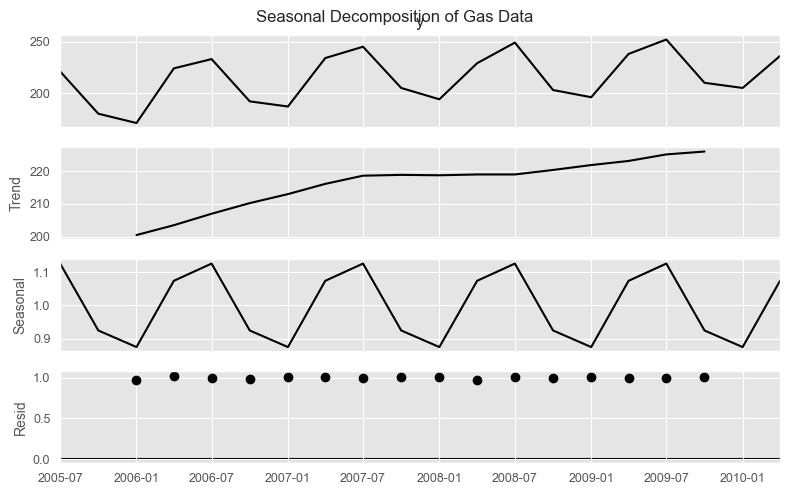

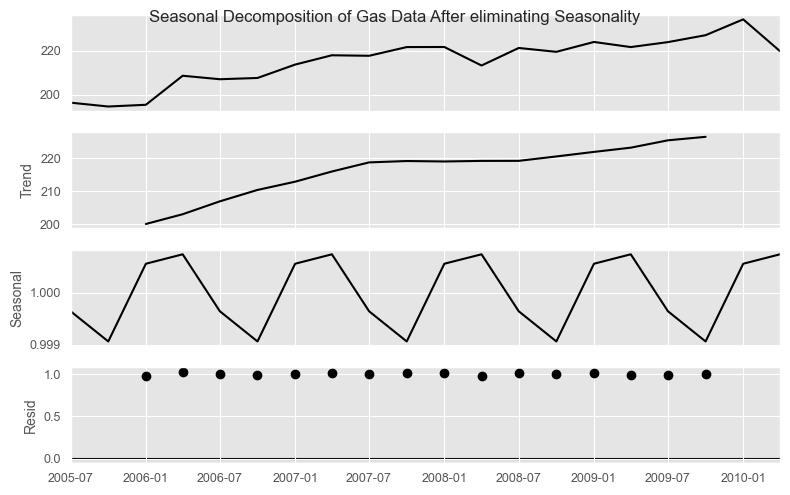

In [155]:
gas = (
    pd.read_csv(DATA_DIR / "aus_production.csv", parse_dates = ['ds'])
    .assign(unique_id = "Gas")
    .loc[lambda x: x["unique_id"] == "Gas"].tail(5 * 4)
    .reset_index()
    .rename(columns = {'Gas': 'y'})
    [['ds', 'unique_id', 'y']]
)
plot_series(gas)

dec = gas.set_index('ds')['y']
fig2 = seasonal_decompose(x = dec, period = 4 , model = 'multiplicative')
fig2.plot()
plt.suptitle('Seasonal Decomposition of Gas Data')
plt.show()

seasonal_component = fig2.seasonal 
seasonally_adjust = dec / seasonal_component
df_adjusted = seasonally_adjust.to_frame(name='seasonally_adjusted')
fig3 = seasonal_decompose(x = df_adjusted, period = 4 , model = 'multiplicative')
fig3.plot()
plt.suptitle('Seasonal Decomposition of Gas Data After eliminating Seasonality')
plt.show()

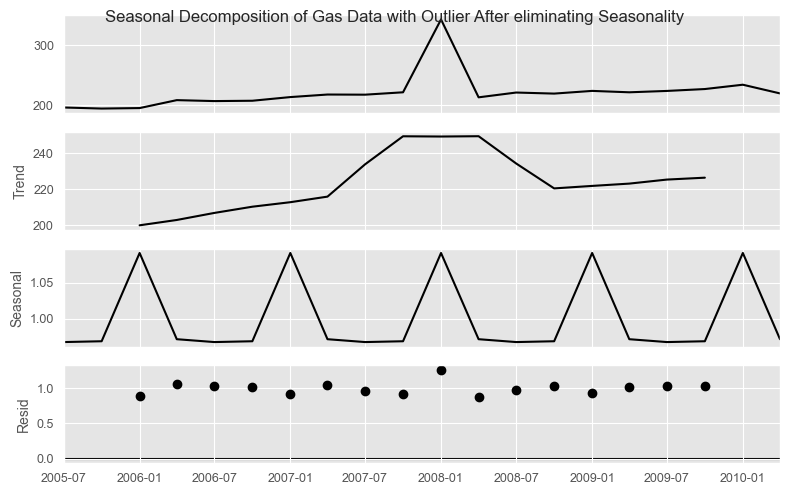

In [156]:
# change a value to outlier
dec.iloc[10] = 300 # thay 10 bằng 19 nếu muốn coi giá trị outlier ở cuối series
dec_outlier = dec.copy()
seasonally_adjust_out = dec_outlier / seasonal_component
df_adjusted_out = seasonally_adjust_out.to_frame(name='seasonally_adjusted')
fig4= seasonal_decompose(x = df_adjusted_out, period = 4 , model = 'multiplicative')
fig4.plot()
plt.suptitle('Seasonal Decomposition of Gas Data with Outlier After eliminating Seasonality')
plt.show()

- First, we can see that seasonal_decompose function is sensitive to outliers by using MA. So, this is the reason why we see a anormal point apperently in the middle of series. 
- if you change the outlier value from the middle to the end, the Trend-cycle would effect less strictful than and Resid should fluctuate randomly around 1.0 (multiplier model) or 0 (additive model).

### 8. Recall your retail time series data (from Exercise 7 in Section 2.10). Decompose the series using the MSTL method. Does it reveal any outliers, or unusual features that you had not noticed previously?

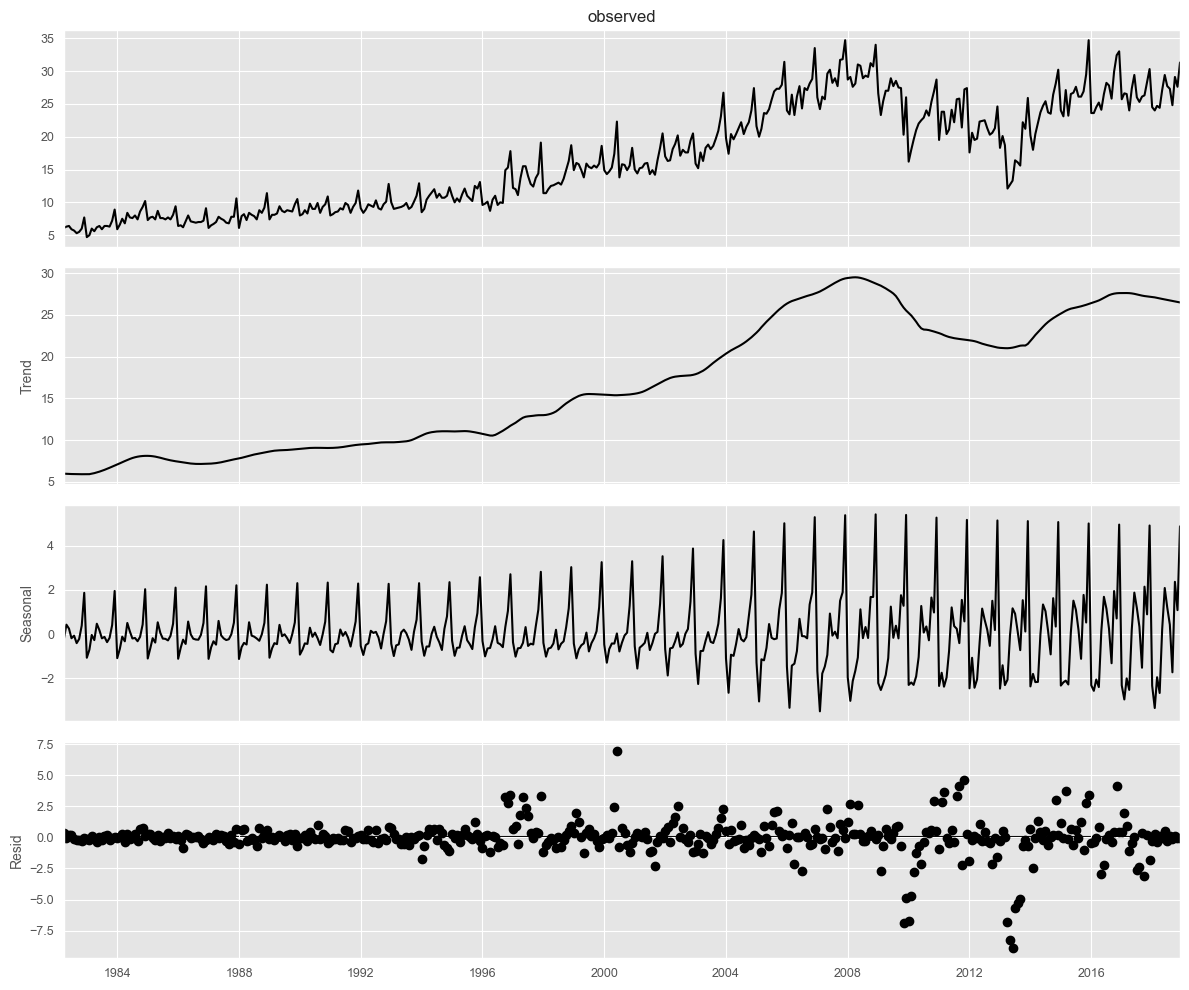

In [ ]:
aus_retail = pd.read_csv(DATA_DIR / "aus_retail.csv", parse_dates = ['Month'])
aus_retail

random = np.random.RandomState(42)
random_series_id = random.choice(aus_retail["Series ID"].unique())
myseries = aus_retail.loc[aus_retail["Series ID"] == random_series_id]

ser = myseries.set_index('Month')['Turnover']
mstl = MSTL(ser, periods=12, stl_kwargs={"robust": True})
res = mstl.fit()
fig = res.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

### 9. Figures 3.15 and 3.16 show the result of decomposing the number of persons in the civilian labour force in Australia each month from February 1978 to August 1995.

- Write about 3–5 sentences describing the results of the decomposition. Pay particular attention to the scales of the graphs in making your interpretation.
- Is the recession of 1991/1992 visible in the estimated components?

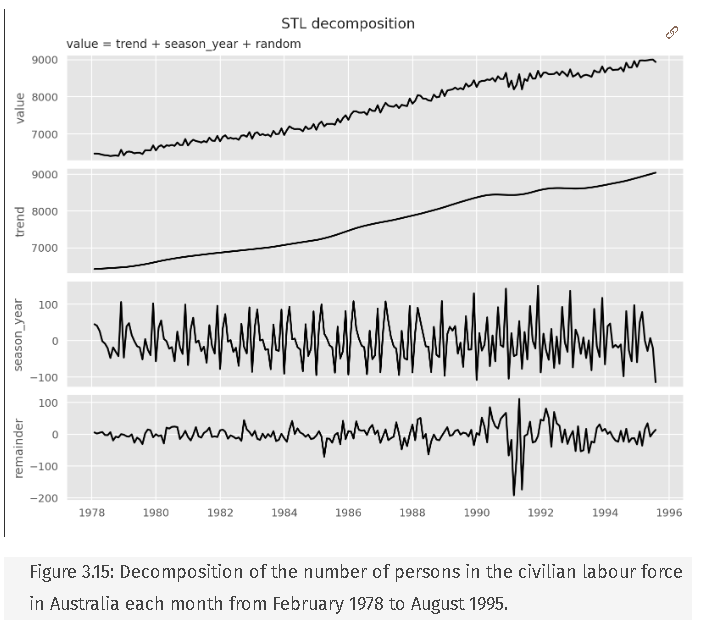

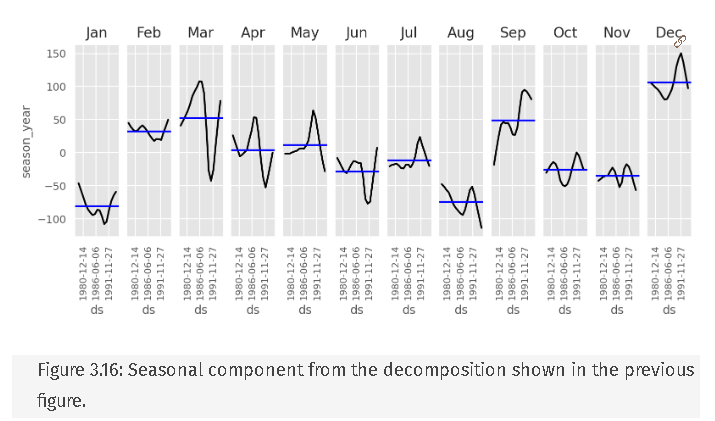


### 10. This exercise uses the canadian_gas data (monthly Canadian gas production in billions of cubic metres, January 1960 – February 2005).
- Plot the data using to look at the effect of the changing seasonality over time.1
- Do an STL decomposition of the data using STL().
- How does the seasonal shape change over time? [Hint: Try plotting the seasonal component.]
- Can you produce a plausible seasonally adjusted series?